### Задача 1

Нормализация матрицы по L1 норме (сумма элементов в каждой сроке матрицы будет = 1)


In [301]:
import numpy as np

A = np.random.random((5,5))

print(A)
print()
print(A.sum(axis=1))
print()
print(A.sum(axis=1).reshape(5, 1))

A = A / A.sum(axis=1).reshape(5, 1)
A

[[0.04632759 0.71028386 0.07533532 0.15214381 0.9756592 ]
 [0.35231751 0.35692157 0.51143026 0.80897113 0.15772313]
 [0.82550821 0.53605535 0.33850486 0.9906546  0.09570836]
 [0.98901627 0.41257154 0.60259094 0.89057975 0.02886509]
 [0.62287693 0.66722311 0.67481086 0.7036437  0.46875623]]

[1.95974978 2.18736361 2.78643139 2.92362358 3.13731082]

[[1.95974978]
 [2.18736361]
 [2.78643139]
 [2.92362358]
 [3.13731082]]


array([[0.02363954, 0.362436  , 0.03844129, 0.07763431, 0.49784886],
       [0.16106947, 0.16317432, 0.23381127, 0.36983844, 0.0721065 ],
       [0.29626002, 0.1923806 , 0.12148329, 0.35552808, 0.034348  ],
       [0.33828441, 0.1411165 , 0.20611099, 0.30461505, 0.00987305],
       [0.19853848, 0.21267358, 0.21509213, 0.22428243, 0.14941338]])

Проверим что исходная матрица не нормализована

In [302]:
np.sum(A, axis=1)[:, np.newaxis]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

### Задача 2

Дан одномерный массив, инвертируйте знак у всех элементов массива, которые находятся в диапазоне от 4 до 8 на месте.

In [303]:
A = np.arange(10)
np.putmask(A, [(A >= 4) & (A <= 8)], -A)
A

array([ 0,  1,  2,  3, -4, -5, -6, -7, -8,  9])

### Задача 3

Создайте структурированный массив, представляющий позицию position (x, y) и цвет color (r, g, b)

Создайте массив из 2х нулевых элементов структурированного типа

Измените 1-й элемент следующим образом
```python
A['position']['x'][0] = 20
A['color']['g'][0] = 0
```

Задайте 2-й элемент напрямую `((10, 5), (255, 255, 255))`

In [304]:
types = np.dtype([
    ('position', [
        ('x', float),
        ('y', float)
    ]),
    ('color', [
        ('r', int),
        ('g', int),
        ('b', int)
    ])
])

A = np.zeros(2, dtype=types)


A['position']['x'][0] = 20
A['color']['g'][0] = 0


A[1] = ((10, 5), (255, 255, 255))

print(A)

[((20., 0.), (  0,   0,   0)) ((10., 5.), (255, 255, 255))]


### Задача 4
Как случайным образом разместить p элементов в 2х мерном массиве?

*смотри `np.put`

In [305]:
N = 6  # размер массива
p = 6  # кол-во элементов, которые нужно случайным образом разместить
el = 1 # сам элемент
A = np.zeros((N,N))

np.put(A, np.random.choice(N * N, p, replace=False), el)
A

array([[1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]])

## Задача 5

Найдите число уникальных цветов и их вес (встречаемость) для изображения ![Python](p.png)

Далее инвертируйте цвета изображения и выведете полученное изображение на экран

34


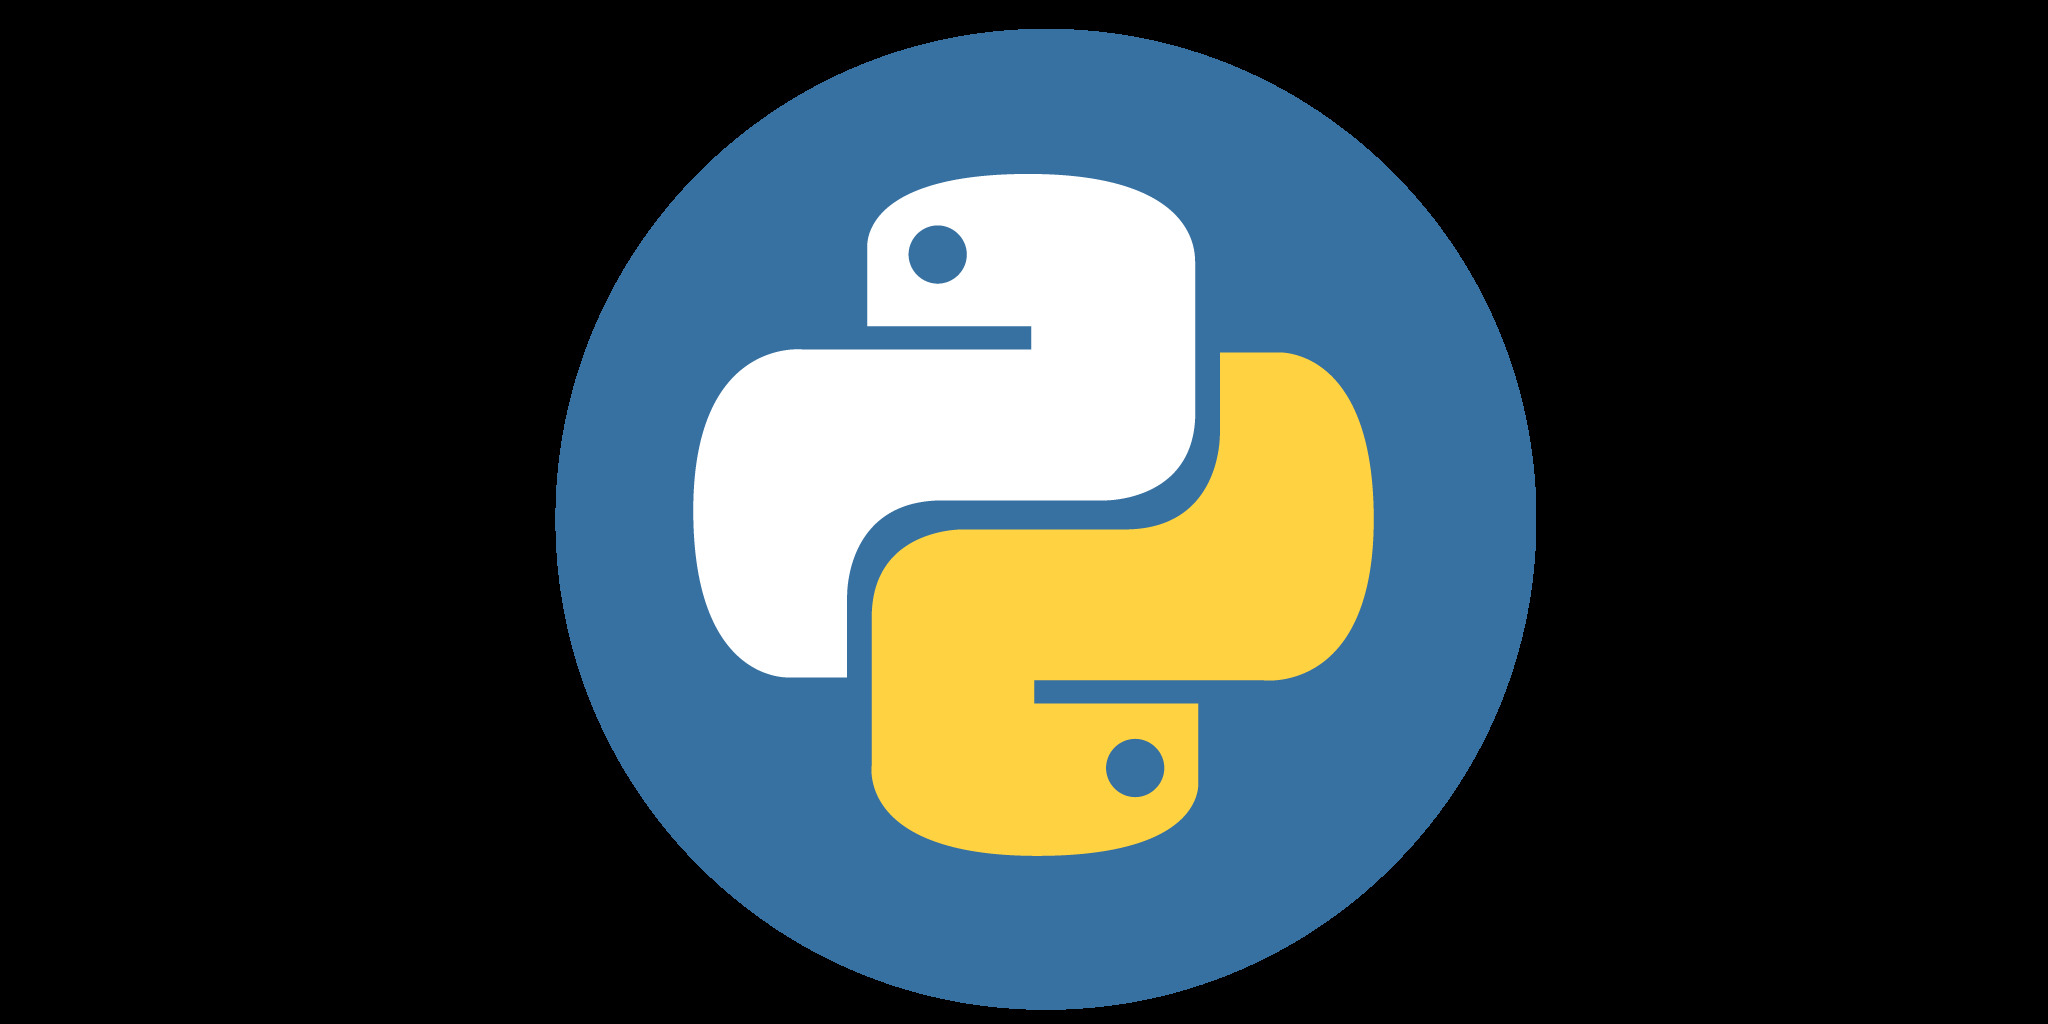

In [306]:
from PIL import Image

image = Image.open('p.png').convert('RGB')

A = np.array(image)
print(len(np.unique(np.concatenate(A, axis=0), axis=0)))

image

In [307]:
A = np.array(image)  # массив пикселей
A.shape

(1024, 2048, 3)

In [308]:
A[0][0]  # первый элемент


array([0, 0, 0], dtype=uint8)

In [309]:
A_unique, counts = np.unique(np.concatenate(A, axis=0), axis=0, return_counts=True)
print(len(A_unique))

percentages = counts / (A.shape[0] * A.shape[1]) * 100

for i in range(len(counts)):
    print(A_unique[i], percentages[i])

34
[0 0 0] 63.92025947570801
[ 55 113 161] 22.31121063232422
[ 68 119 155] 0.005054473876953125
[ 68 122 167] 0.004673004150390625
[ 80 125 149] 0.0034332275390625
[ 80 131 173] 0.0033855438232421875
[ 93 131 143] 0.0029087066650390625
[ 93 140 179] 0.00362396240234375
[105 137 137] 0.02880096435546875
[105 149 185] 0.020503997802734375
[118 143 131] 0.0018596649169921875
[118 157 190] 0.002193450927734375
[130 149 125] 0.003719329833984375
[130 166 196] 0.00362396240234375
[143 155 119] 0.0030040740966796875
[143 175 202] 0.0021457672119140625
[155 162 114] 0.024509429931640625
[155 184 208] 0.027608871459960938
[168 168 108] 0.0023365020751953125
[168 193 214] 0.0024318695068359375
[180 174 102] 0.003337860107421875
[180 202 220] 0.0042438507080078125
[193 180  96] 0.0030040740966796875
[193 211 226] 0.0019073486328125
[205 186  90] 0.005817413330078125
[205 220 232] 0.011873245239257812
[218 192  84] 0.003814697265625
[218 228 237] 0.0029087066650390625
[230 198  78] 0.0032901763916

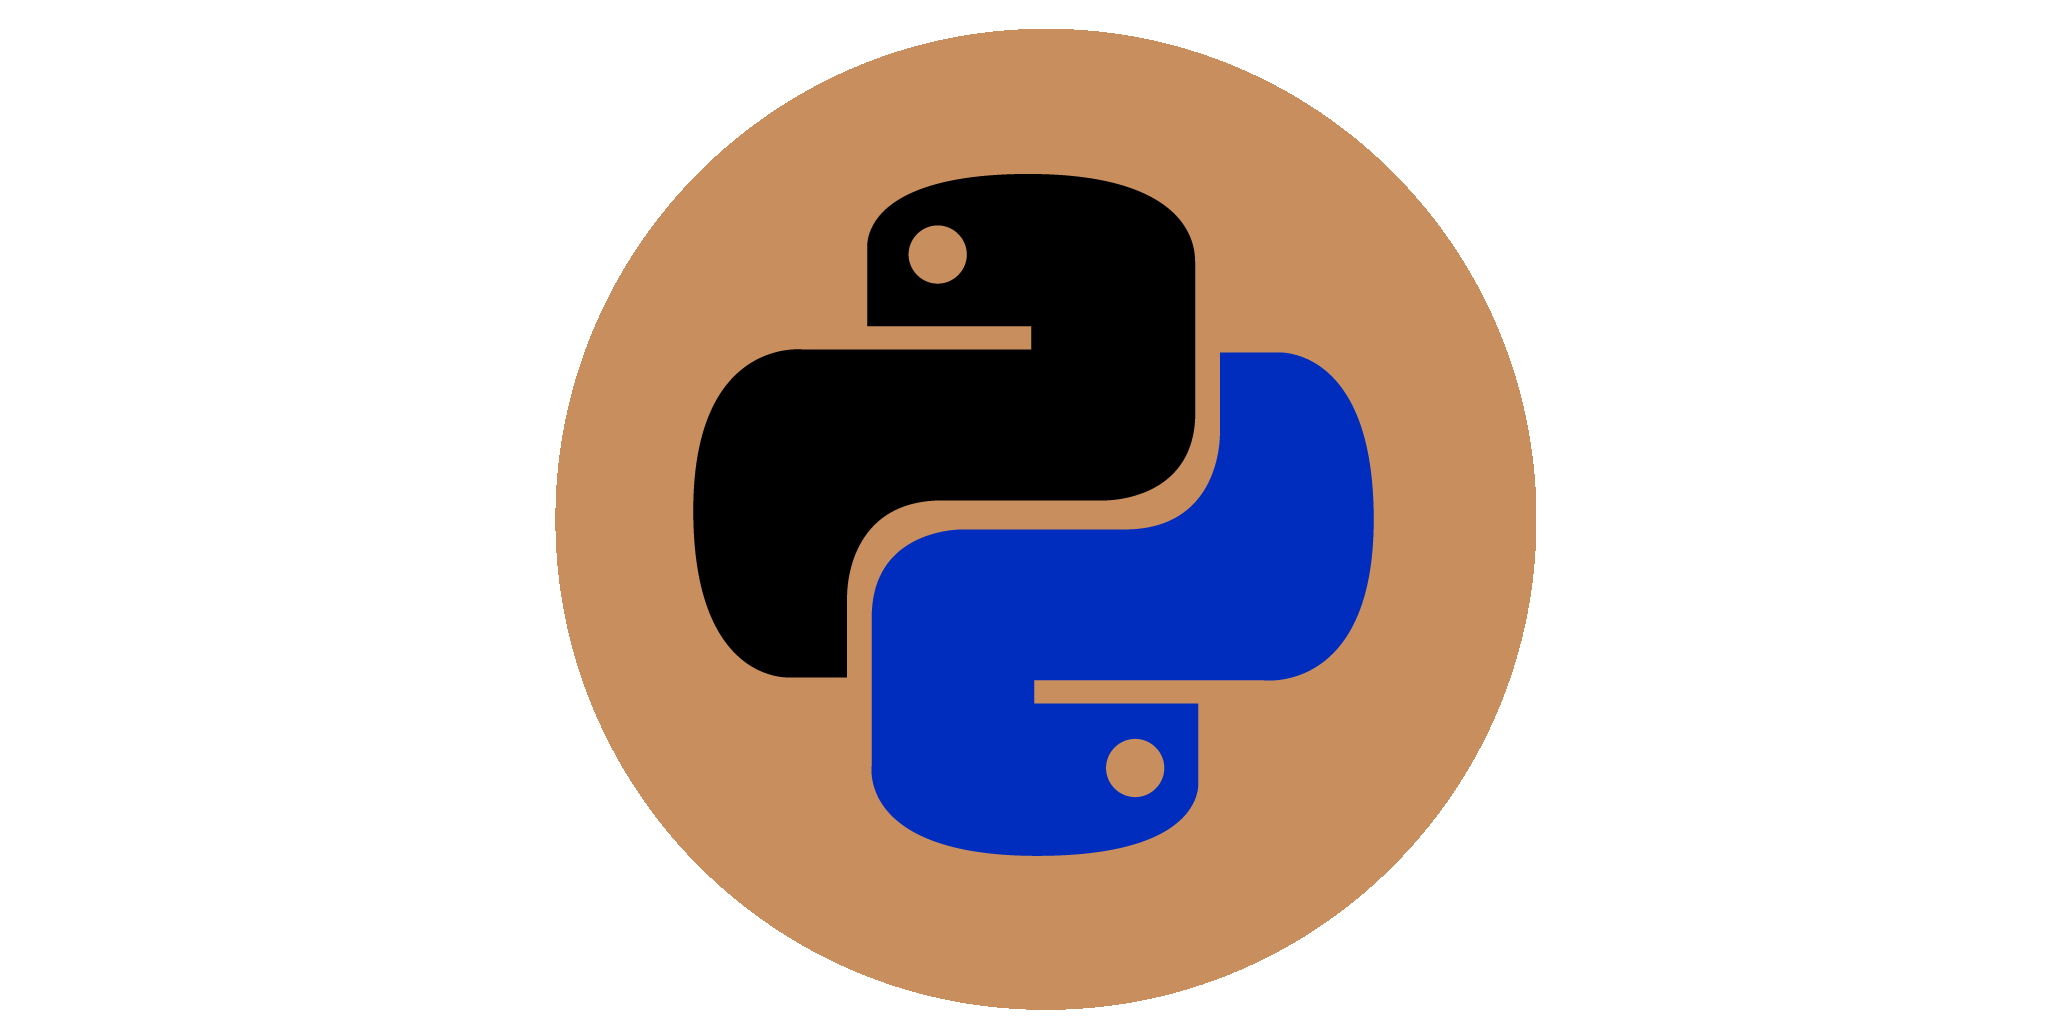

In [ ]:
A_inverted = 255 - A

result = Image.fromarray(A_inverted)
result